# BCI Session 1 – Full Analysis Notebook

This notebook consolidates all analysis steps discussed in our conversation for two sample subjects (`S1_Session_1.mat`, `S2_session_1.mat`). It covers:

1. Environment setup and helper functions
2. Data loading and quality control (bad channels, artifacts)
3. Event-related desynchronisation (ERD) analysis
4. Power spectral density (PSD) and frequency-band features
5. Multifractal detrended fluctuation analysis (MFDFA)
6. Simple left-vs-right motor-imagery classification

Run the notebook top-to-bottom after placing the two `*.mat` files in the same folder.


In [4]:

import os, glob, warnings
import numpy as np
import scipy.io as sio
from scipy.signal import butter, filtfilt, hilbert, welch, coherence
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')
SRATE = 1000  # sampling rate Hz


In [5]:

# 8-30 Hz band-pass and 1 Hz high-pass
_b, _a   = butter(4, [8/(SRATE/2), 30/(SRATE/2)], btype='band')
_bhp, _ahp = butter(4, 1/(SRATE/2), btype='high')

def bandpass(x, b=_b, a=_a):
    return filtfilt(b, a, x, axis=-1, padlen=150)

def highpass(x, b=_bhp, a=_ahp):
    return filtfilt(b, a, x, axis=-1, padlen=150)


In [6]:

files = ['S1_Session_1.mat', 'S2_session_1.mat']
existing = [f for f in files if os.path.exists(f)]
print(f'Found {len(existing)} / {len(files)} files')
if len(existing) < 1:
    raise FileNotFoundError('Place the .mat files next to this notebook and rerun.')

trials_dict, trial_data_dict, subjects = {}, {}, []
for f in existing:
    mat = sio.loadmat(f, squeeze_me=True, struct_as_record=False)
    if 'BCI' not in mat:
        print('BCI struct missing in', f); continue
    BCI = mat['BCI']
    sid = f.split('_')[0]
    trials = [t for t in BCI.data if t is not None]
    trial_meta = list(BCI.TrialData) if hasattr(BCI,'TrialData') else []
    trials_dict[sid] = trials
    trial_data_dict[sid] = trial_meta
    subjects.append({'id':sid})
print('Subjects loaded:', [s['id'] for s in subjects])


Found 2 / 2 files
Subjects loaded: ['S1', 'S2']


S1: 1 bad channels, artifact rate 0.2%
S2: 1 bad channels, artifact rate 0.7%


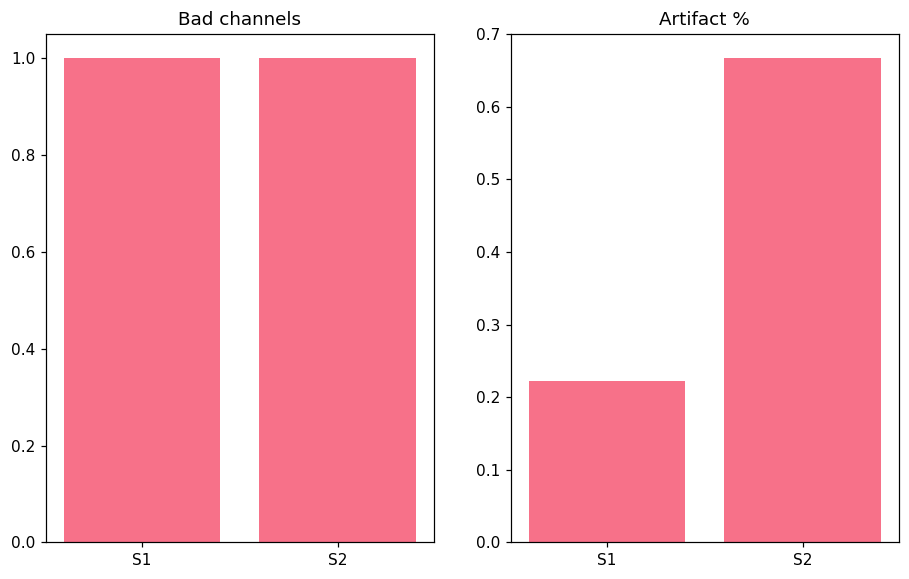

In [8]:

def detect_bad_channels(trials):
    """Detect bad channels with variable-length trial support"""
    if not trials: 
        return []
    
    # Find the minimum length across all trials
    min_length = min(trial.shape[1] for trial in trials if trial is not None)
    
    if min_length < 100:  # Need minimum samples for reliable variance
        print(f"Warning: Very short trials detected (min length: {min_length})")
        return []
    
    # Truncate all trials to minimum length
    truncated_trials = []
    for trial in trials:
        if trial is not None and trial.shape[1] >= min_length:
            truncated_trials.append(trial[:, :min_length])
    
    if not truncated_trials:
        return []
    
    # Now we can safely create the array
    data = np.array(truncated_trials)
    
    # Calculate variance across trials and time
    var_ch = data.var(axis=(0, 2))
    
    # Z-score normalization
    z = (var_ch - var_ch.mean()) / var_ch.std()
    
    # Find bad channels (z > 5)
    bad_channels = np.where(z > 5)[0]
    
    return bad_channels.tolist()


def detect_trial_artifact(trial, bad_channels=None):
    """Detect trial artifacts with optional bad channels parameter"""
    if trial is None:
        return True
    
    try:
        # Apply bandpass filter
        filtered = bandpass(trial)
        
        # Check maximum amplitude
        max_amplitude = np.max(np.abs(filtered))
        
        return max_amplitude > 100
    
    except Exception as e:
        print(f"Error in artifact detection: {e}")
        return True


bad_summary, art_summary = {}, {}
for sid in trials_dict:
    bad = detect_bad_channels(trials_dict[sid])
    art = [detect_trial_artifact(t) for t in trials_dict[sid]]
    bad_summary[sid] = bad
    art_summary[sid] = np.mean(art)
    print(f"{sid}: {len(bad)} bad channels, artifact rate {art_summary[sid]:.1%}")

plt.subplot(1,2,1); plt.bar(bad_summary.keys(), [len(b) for b in bad_summary.values()]);
plt.title('Bad channels'); plt.subplot(1,2,2);
plt.bar(art_summary.keys(), [v*100 for v in art_summary.values()]); plt.title('Artifact %'); plt.show()


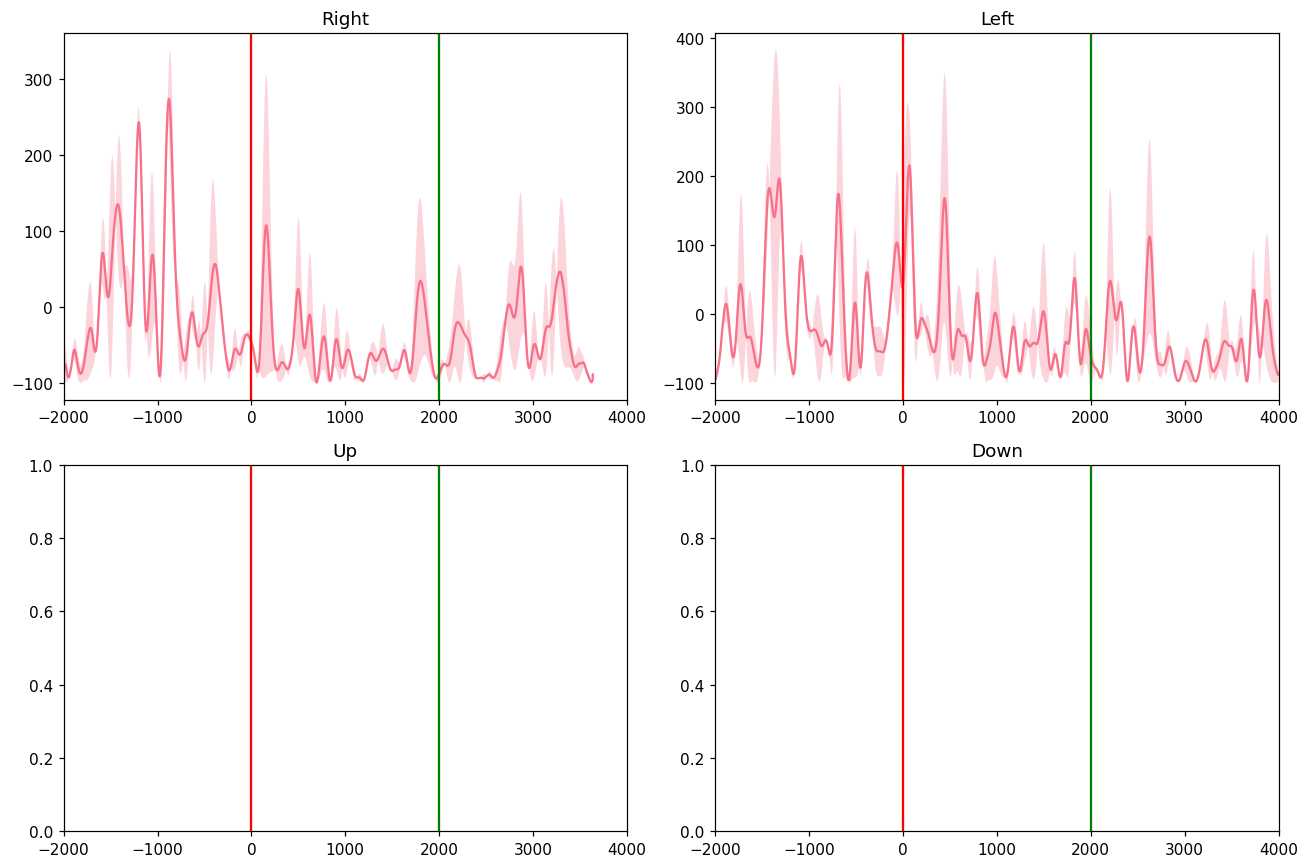

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert
from scipy.interpolate import interp1d

# Define your filter
SRATE = 1000  # Make sure this is defined
b_alpha, a_alpha = butter(4,[8/(SRATE/2),14/(SRATE/2)],btype='band')

def erd_one_robust(sid, task, target, ch=8):
    """Robust ERD analysis using interpolation for length matching"""
    trials = trials_dict[sid]
    trial_data = trial_data_dict[sid]
    
    sigs = []
    
    # Collect signals
    for i, tr in enumerate(trials):
        if (tr is not None and 
            i < len(trial_data) and 
            hasattr(trial_data[i], 'tasknumber') and 
            hasattr(trial_data[i], 'targetnumber') and
            trial_data[i].tasknumber == task and 
            trial_data[i].targetnumber == target and
            tr.shape[0] > ch):
            sigs.append(tr[ch])
    
    if not sigs:
        return None, None
    
    # Find target length (use most common length or median)
    lengths = [len(sig) for sig in sigs]
    target_length = int(np.median(lengths))
    
    # Interpolate all signals to target length
    interpolated_sigs = []
    for sig in sigs:
        if len(sig) >= target_length * 0.8:  # Only use signals that aren't too short
            # Create interpolation function
            old_indices = np.linspace(0, len(sig)-1, len(sig))
            new_indices = np.linspace(0, len(sig)-1, target_length)
            
            # Interpolate
            f = interp1d(old_indices, sig, kind='linear', bounds_error=False, fill_value='extrapolate')
            interpolated_sig = f(new_indices)
            interpolated_sigs.append(interpolated_sig)
    
    if not interpolated_sigs:
        return None, None
    
    # Average interpolated signals
    avg = np.mean(interpolated_sigs, 0)
    
    # ERD analysis
    env = np.abs(hilbert(filtfilt(b_alpha, a_alpha, highpass(avg))))**2
    t = np.linspace(-2000, 4000, len(env))
    
    # Baseline correction
    baseline_mask = (t >= -1000) & (t <= 0)
    if np.sum(baseline_mask) > 0:
        baseline_power = np.mean(env[baseline_mask])
        erd = 100 * (env - baseline_power) / baseline_power
        return t, erd
    else:
        return t, env

# Plotting with corrected function call
conditions=[('Right',1,1),('Left',1,2),('Up',2,1),('Down',2,2)]
fig,axs=plt.subplots(2,2,figsize=(12,8))

for ax,(name,tsk,tgt) in zip(axs.ravel(),conditions):
    all_erd=[]
    all_times=[]
    
    for sid in trials_dict:
        t,e=erd_one_robust(sid,tsk,tgt)
        if e is not None: 
            all_erd.append(e)
            all_times.append(t)
    
    if all_erd:
        # **KEY FIX: Ensure all ERD arrays have same length**
        min_length = min(len(erd) for erd in all_erd)
        
        # Truncate all ERD arrays to minimum length
        truncated_erd = [erd[:min_length] for erd in all_erd]
        
        # Use corresponding time vector
        t_common = all_times[0][:min_length]
        
        # Now averaging will work
        m=np.mean(truncated_erd,0)
        s=np.std(truncated_erd,0)
        
        ax.plot(t_common,m)
        ax.fill_between(t_common,m-s,m+s,alpha=.3)
    
    ax.set_title(name)
    ax.set_xlim(-2000,4000)
    ax.axvline(0,color='r')
    ax.axvline(2000,color='g')

plt.tight_layout()
plt.show()



Text(0.5, 1.0, 'Motor-channel PSD')

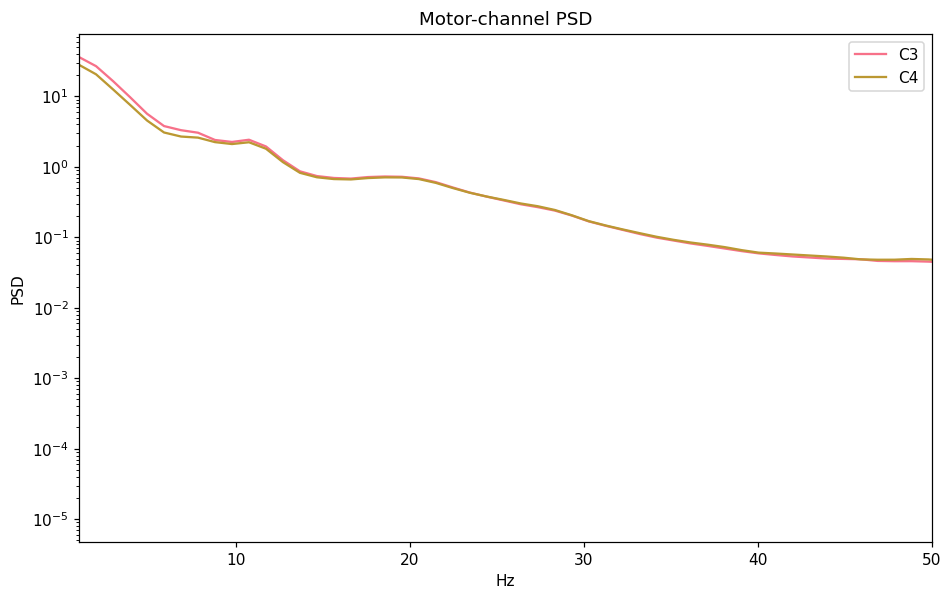

In [14]:

fig,ax=plt.subplots()
for ch,name in zip([8,10],["C3","C4"]):
    psds=[]; freqs=None
    for sid in trials_dict:
        dat=np.concatenate([tr[ch] for tr in trials_dict[sid]],axis=None)
        f,p=welch(dat,fs=SRATE,nperseg=1024)
        freqs=f; psds.append(p)
    ax.semilogy(freqs,np.mean(psds,0),label=name)
ax.set_xlim(1,50); ax.set_xlabel('Hz'); ax.set_ylabel('PSD'); ax.legend(); ax.set_title('Motor-channel PSD')


Text(0.5, 1.0, 'MFDFA')

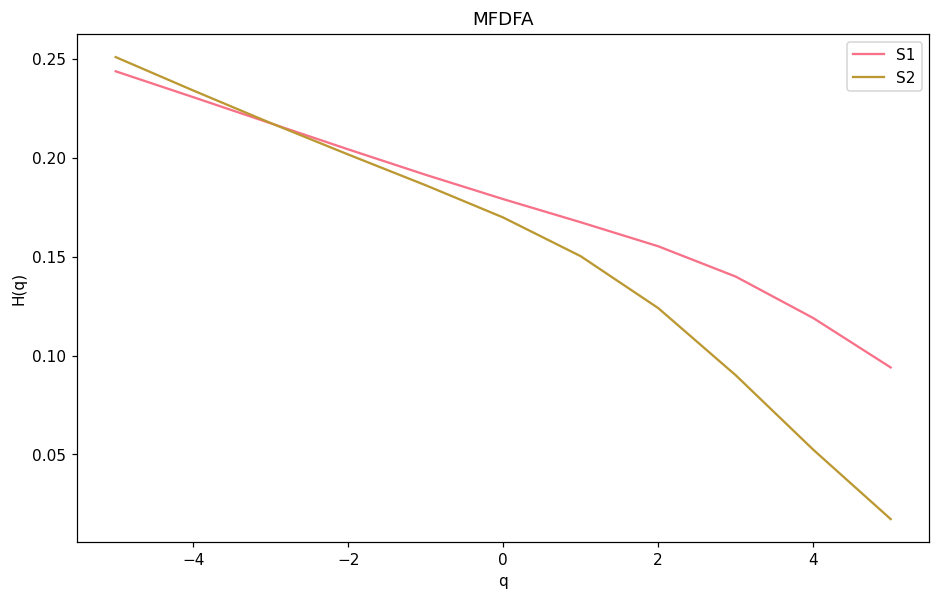

In [15]:

qs=np.arange(-5,6)
fig,ax=plt.subplots()
for sid in trials_dict:
    sig=np.concatenate([tr[8,4000:6000] for tr in trials_dict[sid] if tr.shape[1]>=6000])
    if len(sig)<5000: continue
    sig=highpass(sig)
    N=len(sig); scales=np.logspace(2,3,12).astype(int)
    H=[]
    for q in qs:
        Fq=[]
        for s in scales:
            Ns=N//s
            if Ns<2: continue
            rms=[]
            for v in range(Ns):
                seg=sig[v*s:(v+1)*s]
                rms.append(np.sqrt(np.mean((seg-np.mean(seg))**2)))
            Fq.append((np.mean(np.array(rms)**q))**(1/q) if q!=0 else np.exp(np.mean(np.log(rms))))
        if len(Fq)>2:
            H.append(np.polyfit(np.log2(scales[:len(Fq)]),np.log2(Fq),1)[0])
        else:
            H.append(np.nan)
    ax.plot(qs,H,label=sid)
ax.set_xlabel('q'); ax.set_ylabel('H(q)'); ax.legend(); ax.set_title('MFDFA')


In [16]:

X,y=[],[]
for sid in trials_dict:
    for tr,meta in zip(trials_dict[sid],trial_data_dict[sid]):
        if meta.tasknumber==1 and meta.targetnumber in [1,2]:
            feat=[]
            for ch in [8,10]:
                seg=tr[ch,2000:4000]
                a=filtfilt(*butter(4,[8/500,13/500],btype='band'),seg); feat.append(np.mean(a**2))
                b=filtfilt(*butter(4,[13/500,30/500],btype='band'),seg); feat.append(np.mean(b**2))
            X.append(feat); y.append(meta.targetnumber)
X=np.array(X); y=np.array(y)
if len(np.unique(y))>1:
    X=StandardScaler().fit_transform(X)
    acc=cross_val_score(LDA(),X,y,cv=3).mean()
    print(f'LDA accuracy: {acc:.3f} (n={len(y)} trials)')


LDA accuracy: 0.517 (n=300 trials)
